In [1]:
import numpy as np
from mp_api.client import MPRester
from matminer.featurizers.site import CrystalNNFingerprint
from matminer.featurizers.structure import SiteStatsFingerprint
from api import api

with MPRester(api()) as mpr:

    # Get structures.
    diamond = mpr.get_structure_by_material_id("mp-66")
    gaas = mpr.get_structure_by_material_id("mp-2534")
    rocksalt = mpr.get_structure_by_material_id("mp-22862")
    perovskite = mpr.get_structure_by_material_id("mp-5827")
    #spinel_caco2s4 = mpr.get_structure_by_material_id("mvc-12728")
    spinel_sicd2O4 = mpr.get_structure_by_material_id("mp-560842")

    # Calculate structure fingerprints.
    ssf = SiteStatsFingerprint(
        CrystalNNFingerprint.from_preset('ops', distance_cutoffs=None, x_diff_weight=0),
        stats=('mean', 'std_dev', 'minimum', 'maximum'))
    v_diamond = np.array(ssf.featurize(diamond))
    v_gaas = np.array(ssf.featurize(gaas))
    v_rocksalt = np.array(ssf.featurize(rocksalt))
    v_perovskite = np.array(ssf.featurize(perovskite))
    #v_spinel_caco2s4 = np.array(ssf.featurize(spinel_caco2s4))
    v_spinel_sicd2O4 = np.array(ssf.featurize(spinel_sicd2O4))

    # Print out distance between structures.
    print('Distance between diamond and GaAs: {:.4f}'.format(np.linalg.norm(v_diamond - v_gaas)))
    print('Distance between diamond and rocksalt: {:.4f}'.format(np.linalg.norm(v_diamond - v_rocksalt)))
    print('Distance between diamond and perovskite: {:.4f}'.format(np.linalg.norm(v_diamond - v_perovskite)))
    print('Distance between rocksalt and perovskite: {:.4f}'.format(np.linalg.norm(v_rocksalt - v_perovskite)))
    #print('Distance between Ca(CoS2)2-spinel and Si(CdO2)2-spinel: {:.4f}'.format(np.linalg.norm(v_spinel_caco2s4 - v_spinel_sicd2O4)))

/Users/sisi1/Documents/RA_Structure_matcher/Matminer_matcher-1/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Retrieving MaterialsDoc documents: 100%|██████████| 1/1 [00:00<00:00, 37449.14it/s]


Distance between diamond and GaAs: 0.0000
Distance between diamond and rocksalt: 3.5724
Distance between diamond and perovskite: 3.5540
Distance between rocksalt and perovskite: 2.7417


In [14]:
import os
import glob
from typing import Dict, Any, Iterable, Tuple, Optional
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def _find_column(df: pd.DataFrame, candidates: Iterable[str]) -> Optional[str]:
    keys = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in keys:
            return keys[cand.lower()]
    return None

def read_xrd_csv(folder_path: str,
                 file_pattern: str = "*.csv",
                 two_theta_candidates: Tuple[str, ...] = ("2theta", "2θ", "two_theta", "two-theta", "theta"),
                 intensity_candidates: Tuple[str, ...] = ("intensity", "i", "counts", "count", "intensity_counts"),
                 use_pymatgen_pattern: bool = True
                 ) -> Tuple[list, list]:
    """
    指定フォルダ内のCSVファイルを読み、XRDデータ（2θ と 強度）をリストで返す関数。
    戻り値は (results_list, filenames_list) のタプル。
    各 results_list の要素は以下のいずれか：
      - pymatgen の XRDPattern オブジェクト（利用可能で use_pymatgen_pattern=True の場合）
      - {'two_theta': np.ndarray, 'intensity': np.ndarray}
      - {'error': str}（読み込みに失敗した場合）
    CSVのカラム名は複数の候補名に対応。自動検出できない場合は先頭2列を使用します。
    コメント行（先頭に #）は無視します。
    """
    results_list: list = []
    filenames_list: list = []
    csv_files = sorted(glob.glob(os.path.join(folder_path, file_pattern)))

    # try import XRDPattern if requested
    XRDPattern = None
    if use_pymatgen_pattern:
        try:
            from pymatgen.analysis.diffraction.xrd import XRDPattern  # type: ignore
        except Exception:
            XRDPattern = None

    for f in csv_files:
        basename = os.path.basename(f)
        try:
            df = pd.read_csv(f, comment="#", engine="python")
            # drop completely empty columns
            df = df.dropna(axis=1, how="all")
            if df.shape[1] == 0:
                raise ValueError("no data columns")

            # find columns
            col_tt = _find_column(df, two_theta_candidates)
            col_int = _find_column(df, intensity_candidates)

            if col_tt is None or col_int is None:
                # fallback to first two columns
                col_tt = df.columns[0]
                if df.shape[1] >= 2:
                    col_int = df.columns[1]
                else:
                    raise ValueError("cannot locate intensity column")

            tt = pd.to_numeric(df[col_tt], errors="coerce").to_numpy(dtype=float)
            intensity = pd.to_numeric(df[col_int], errors="coerce").to_numpy(dtype=float)

            # remove nan pairs
            mask = np.isfinite(tt) & np.isfinite(intensity)
            tt = tt[mask]
            intensity = intensity[mask]

            # ensure 1D arrays
            tt = np.asarray(tt).ravel()
            intensity = np.asarray(intensity).ravel()

            if use_pymatgen_pattern and XRDPattern is not None:
                # XRDPattern expects (x, y) arrays; handle gracefully
                try:
                    pat = XRDPattern(tt, intensity)
                    results_list.append(pat)
                    filenames_list.append(basename)
                except Exception:
                    # fallback to dict if construction fails
                    results_list.append({"two_theta": tt, "intensity": intensity})
                    filenames_list.append(basename)
            else:
                results_list.append({"two_theta": tt, "intensity": intensity})
                filenames_list.append(basename)

        except Exception as e:
            # store error info instead of raising to allow batch processing
            results_list.append({"error": str(e)})
            filenames_list.append(basename)

    return results_list, filenames_list

from matminer.featurizers.structure import XRDPowderPattern
from pymatgen.analysis.diffraction.xrd import XRDCalculator

def str_strdist(xrd_data):
    # Calculate structure fingerprints.
    ssf = SiteStatsFingerprint(
        CrystalNNFingerprint.from_preset('ops', distance_cutoffs=None, x_diff_weight=0),
        stats=('mean', 'std_dev', 'minimum', 'maximum'))

    if type(xrd_data) is list:
        featlist=[]
        
        for xrd in xrd_data:
            try:
                a=np.array(ssf.featurize(xrd))
                featlist.append(a)
            except Exception:
                a=np.array(ssf.featurize(XRDCalculator(wavelength="CuKa").get_pattern(xrd)))
                featlist.append(a)
        return featlist
    
    else:
        try:
            return np.array(ssf.featurize(xrd_data))
        except Exception:
            print("Invalid xrd_data type")
            raise TypeError("Something is wrong with xrd_data!!")
        
## XRD pattern distance by matminer
def xrd_strdist(xrd_data):
    """
XRDパターンの指紋を計算します。

パラメータ

----------

Xrd_data：dictまたはdictのリスト

Dictの場合、対応するnumpy配列を持つキー「two_theta」と「intensity」が必要です。

リストの場合、各要素はそのような辞書である必要があります。

返品

-------

Np.ndarrayまたはnp.ndarrayのリスト

XRDパターンはnumpy配列としてフィンガープリンティングします。
    """
    # Calculate structure fingerprints.
    ssf = XRDPowderPattern()

    #adpc = XRDCalculator(wavelength="CuKa")
    # give pymatgen.core.structure.Structure object to get_pattern method
    #v_diamond = np.array(ssf.featurize(diamond))
    if type(xrd_data) is list:
        featlist=[]
        
        for xrd in xrd_data:
            if type(xrd) =="array":
                a=np.array(ssf.featurize(xrd))
                featlist.append(a)
            else:
                a=np.array(ssf.featurize(XRDCalculator(wavelength="CuKa").get_pattern(xrd)))
                featlist.append(a)
        return featlist
    
    else:
        try:
            return np.array(ssf.featurize(xrd_data))
        except Exception:
            print("Invalid xrd_data type")
            raise TypeError("Something is wrong with xrd_data!!")
    #v_spinel_caco2s4 = np.array(ssf.featurize(adpc.get_pattern(spinel_caco2s4)))
    #v_spinel_sicd2O4 = np.array(ssf.featurize(spinel_sicd2O4))

    # Print out distance between structures.
    #print('Distance between diamond and GaAs: {:.4f}'.format(np.linalg.norm(v_diamond - v_gaas)))

def postprocess(processed_data):
    '''
    Calculate distance matrix from processed fingerprints.
    '''
    if type(processed_data) ==list:
        
        matrix=np.full((len(processed_data), len(processed_data)), np.nan)
        #matrix=np.zeros((len(processed_data), len(processed_data)))
        
        for data in range(0,len(processed_data)):
            for data2 in range(data):
                #print(data,data2)
                matrix[data][data2]=np.linalg.norm(processed_data[data] -processed_data[data2])
        return matrix
    else:
        return np.array(ssf.featurize(processed_data))

def visualize_distance_matrix(distance_matrix, filenames, rank: int=3):
    """
    Visualize distance matrix and print the 3 smallest pairwise distances (excluding diagonal/duplicates).
    Returns a list of tuples: (filename_i, filename_j, distance).
    """        
    import matplotlib.pyplot as plt        
    plt.figure(figsize=(10, 8))
    sns.heatmap(distance_matrix, xticklabels=filenames, yticklabels=filenames, annot=True, fmt=".2f", cmap="viridis")
    plt.title("XRD Pattern Distance Matrix")
    plt.xlabel("Samples")
    plt.ylabel("Samples")
    plt.tight_layout()
    plt.show()
    dm = np.asarray(distance_matrix)
    if dm.ndim != 2 or dm.shape[0] != dm.shape[1]:
        raise ValueError("distance_matrix must be a square 2D array")

    # Consider only one triangle to avoid duplicate pairs (use lower triangle excluding diagonal)
    tri_rows, tri_cols = np.tril_indices(dm.shape[0], k=-1)
    tri_vals = dm[tri_rows, tri_cols]

    finite_mask = np.isfinite(tri_vals)
    if not np.any(finite_mask):
        print("No finite off-diagonal distances found.")
        return []

    finite_rows = tri_rows[finite_mask]
    finite_cols = tri_cols[finite_mask]
    finite_vals = tri_vals[finite_mask]

    order = np.argsort(finite_vals)
    n = min(rank, len(order))

    smallest_pairs = []
    print(f"Bottom {n} smallest pairs:")
    for rank in range(n):
        idx = order[rank]
        i = finite_rows[idx]
        j = finite_cols[idx]
        dist = float(finite_vals[idx])
        print(f"{rank+1}: {filenames[i]} - {filenames[j]} : {dist:.6f}")

In [27]:
from __future__ import annotations

import math
import os
from typing import TYPE_CHECKING

import numpy as np
import orjson

from pymatgen.analysis.diffraction.core import (
    AbstractDiffractionPatternCalculator,
    DiffractionPattern,
    get_unique_families,
)
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

if TYPE_CHECKING:
    from pymatgen.core import Structure

# XRD wavelengths in angstroms
WAVELENGTHS = {
    "CuKa": 1.54184,
    "CuKa2": 1.54439,
    "CuKa1": 1.54056,
    "CuKb1": 1.39222,
    "MoKa": 0.71073,
    "MoKa2": 0.71359,
    "MoKa1": 0.70930,
    "MoKb1": 0.63229,
    "CrKa": 2.29100,
    "CrKa2": 2.29361,
    "CrKa1": 2.28970,
    "CrKb1": 2.08487,
    "FeKa": 1.93735,
    "FeKa2": 1.93998,
    "FeKa1": 1.93604,
    "FeKb1": 1.75661,
    "CoKa": 1.79026,
    "CoKa2": 1.79285,
    "CoKa1": 1.78896,
    "CoKb1": 1.63079,
    "AgKa": 0.560885,
    "AgKa2": 0.563813,
    "AgKa1": 0.559421,
    "AgKb1": 0.497082,
}

class XRDCalculator(AbstractDiffractionPatternCalculator):
    r"""
    Computes the XRD pattern of a crystal structure.

    This code is implemented by Shyue Ping Ong as part of UCSD's NANO106 -
    Crystallography of Materials. The formalism for this code is based on
    that given in Chapters 11 and 12 of Structure of Materials by Marc De
    Graef and Michael E. McHenry. This takes into account the atomic
    scattering factors and the Lorentz polarization factor, but not
    the Debye-Waller (temperature) factor (for which data is typically not
    available). Note that the multiplicity correction is not needed since
    this code simply goes through all reciprocal points within the limiting
    sphere, which includes all symmetrically equivalent facets. The algorithm
    is as follows

    1. Calculate reciprocal lattice of structure. Find all reciprocal points
       within the limiting sphere given by \frac{2}{\lambda}.

    2. For each reciprocal point \mathbf{g_{hkl}} corresponding to
       lattice plane (hkl), compute the Bragg condition
       \sin(\theta) = \frac{ \lambda}{2d_{hkl}}

    3. Compute the structure factor as the sum of the atomic scattering
       factors. The atomic scattering factors are given by

           f(s) = Z - 41.78214 \times s^2 \times \sum \limits_{i=1}^n a_i \exp(-b_is^2)

       where s = \ frac{\ sin(\ theta)}{\ lambda} and a_i
       and b_i are the fitted parameters for each element. The
       structure factor is then given by

           F_{hkl} = \sum \limits_{j=1}^N f_j  \exp(2 \pi i  \mathbf{g_{hkl}} \cdot  \mathbf{r})

    4. The intensity is then given by the modulus square of the structure factor.

           I_{hkl} = F_{hkl}F_{hkl}^*

    5. Finally, the Lorentz polarization correction factor is applied. This
       factor is given by:

           P(\theta) = \frac{1 + \cos^2(2 \theta)}{\sin^2(\theta) \cos(\theta)}
    """

    # Tuple of available radiation keywords.
    AVAILABLE_RADIATION = tuple(WAVELENGTHS)

    def __init__(self, wavelength="CuKa", symprec: float = 0, debye_waller_factors=None):
        """Initialize the XRD calculator with a given radiation.

        Args:
            wavelength (str | float): The wavelength can be specified as either a
                float or a string. If it is a string, it must be one of the
                supported definitions in the AVAILABLE_RADIATION class
                variable, which provides useful commonly used wavelengths.
                If it is a float, it is interpreted as a wavelength in
                angstroms. Defaults to "CuKa", i.e, Cu K_alpha radiation.
            symprec (float): Symmetry precision for structure refinement. If
                set to 0, no refinement is done. Otherwise, refinement is
                performed using spglib with provided precision.
            debye_waller_factors ({element symbol: float}): Allows the
                specification of Debye-Waller factors. Note that these
                factors are temperature dependent.
        """
        if isinstance(wavelength, float | int):
            self.wavelength = wavelength
        elif isinstance(wavelength, str):
            self.radiation = wavelength
            self.wavelength = WAVELENGTHS[wavelength]
        else:
            wavelength_type = type(wavelength).__name__
            raise TypeError(f"{wavelength_type=} must be either float, int or str")
        self.symprec = symprec
        self.debye_waller_factors = debye_waller_factors or {}

    def get_pattern(self, structure: Structure, scaled=True, two_theta_range=(0, 90)):
        """
        Calculates the diffraction pattern for a structure.

        Args:
            structure (Structure): Input structure
            scaled (bool): Whether to return scaled intensities. The maximum
                peak is set to a value of 100. Defaults to True. Use False if
                you need the absolute values to combine XRD plots.
            two_theta_range ([float of length 2]): Tuple for range of
                two_thetas to calculate in degrees. Defaults to (0, 90). Set to
                None if you want all diffracted beams within the limiting
                sphere of radius 2 / wavelength.

        Returns:
            DiffractionPattern: XRD pattern
        """
        if self.symprec:
            finder = SpacegroupAnalyzer(structure, symprec=self.symprec)
            structure = finder.get_refined_structure()

        wavelength = self.wavelength
        lattice = structure.lattice
        is_hex = lattice.is_hexagonal()

        # Obtained from Bragg condition. Note that reciprocal lattice
        # vector length is 1 / d_hkl.
        min_r, max_r = (
            (0, 2 / wavelength)
            if two_theta_range is None
            else [2 * math.sin(math.radians(t / 2)) / wavelength for t in two_theta_range]
        )

        # Obtain crystallographic reciprocal lattice points within range
        recip_lattice = lattice.reciprocal_lattice_crystallographic
        recip_pts = recip_lattice.get_points_in_sphere([[0, 0, 0]], [0, 0, 0], max_r)
        if min_r:
            recip_pts = [pt for pt in recip_pts if pt[1] >= min_r]

        # Create a flattened array of zs, coeffs, frac_coords and occus. This is used to perform
        # vectorized computation of atomic scattering factors later. Note that these are not
        # necessarily the same size as the structure as each partially occupied specie occupies its
        # own position in the flattened array.
        _zs = []
        _coeffs = []
        _frac_coords = []
        _occus = []
        _dw_factors = []

        for site in structure:
            for sp, occu in site.species.items():
                _zs.append(sp.Z)
                try:
                    c = ATOMIC_SCATTERING_PARAMS[sp.symbol]
                except KeyError:
                    raise ValueError(
                        f"Unable to calculate XRD pattern as there is no scattering coefficients for {sp.symbol}."
                    )
                _coeffs.append(c)
                _dw_factors.append(self.debye_waller_factors.get(sp.symbol, 0))
                _frac_coords.append(site.frac_coords)
                _occus.append(occu)

        zs = np.array(_zs)
        coeffs = np.array(_coeffs)
        frac_coords = np.array(_frac_coords)
        occus = np.array(_occus)
        dw_factors = np.array(_dw_factors)
        peaks: dict[float, list[float | list[tuple[int, ...]]]] = {}
        two_thetas: list[float] = []

        for hkl, g_hkl, ind, _ in sorted(recip_pts, key=lambda i: (i[1], -i[0][0], -i[0][1], -i[0][2])):
            # Force miller indices to be integers
            hkl = [round(i) for i in hkl]
            if g_hkl != 0:
                # Bragg condition
                theta = math.asin(wavelength * g_hkl / 2)

                # s = sin(theta) / wavelength = 1 / 2d = |ghkl| / 2 (d =
                # 1/|ghkl|)
                s = g_hkl / 2

                # Store s^2 since we are using it a few times
                s2 = s**2

                # Vectorized computation of g.r for all fractional coords and
                # hkl
                g_dot_r = np.dot(frac_coords, np.transpose([hkl])).T[0]

                # Highly vectorized computation of atomic scattering factors.
                # Equivalent non-vectorized code is:
                #
                #   for site in structure:
                #      el = site.specie
                #      coeff = ATOMIC_SCATTERING_PARAMS[el.symbol]
                #      fs = el.Z - 41.78214 * s2 * sum(
                #          [d[0] * exp(-d[1] * s2) for d in coeff])
                fs = zs - 41.78214 * s2 * np.sum(
                    coeffs[:, :, 0] * np.exp(-coeffs[:, :, 1] * s2),
                    axis=1,
                )

                dw_correction = np.exp(-dw_factors * s2)

                # Structure factor = sum of atomic scattering factors (with
                # position factor exp(2j * pi * g.r and occupancies).
                # Vectorized computation.
                f_hkl = np.sum(fs * occus * np.exp(2j * np.pi * g_dot_r) * dw_correction)

                # Lorentz polarization correction for hkl
                lorentz_factor = (1 + math.cos(2 * theta) ** 2) / (math.sin(theta) ** 2 * math.cos(theta))

                # Intensity for hkl is modulus square of structure factor
                i_hkl = (f_hkl * f_hkl.conjugate()).real

                two_theta = math.degrees(2 * theta)

                if is_hex:
                    # Use Miller-Bravais indices for hexagonal lattices
                    hkl = (hkl[0], hkl[1], -hkl[0] - hkl[1], hkl[2])
                # Deal with floating point precision issues
                ind = np.where(
                    np.abs(np.subtract(two_thetas, two_theta)) < AbstractDiffractionPatternCalculator.TWO_THETA_TOL
                )
                if len(ind[0]) > 0:
                    peaks[two_thetas[ind[0][0]]][0] += i_hkl * lorentz_factor
                    peaks[two_thetas[ind[0][0]]][1].append(tuple(hkl))  # type: ignore[union-attr]
                else:
                    d_hkl = 1 / g_hkl
                    peaks[two_theta] = [i_hkl * lorentz_factor, [tuple(hkl)], d_hkl]
                    two_thetas.append(two_theta)

        # Scale intensities so that the max intensity is 100
        max_intensity = max(v[0] for v in peaks.values())
        x = []
        y = []
        hkls = []
        d_hkls = []
        for k in sorted(peaks):
            v = peaks[k]
            fam = get_unique_families(v[1])
            if v[0] / max_intensity * 100 > AbstractDiffractionPatternCalculator.SCALED_INTENSITY_TOL:  # type: ignore[operator]
                x.append(k)
                y.append(v[0])
                hkls.append([{"hkl": hkl, "multiplicity": mult} for hkl, mult in fam.items()])
                d_hkls.append(v[2])
        xrd = DiffractionPattern(x, y, hkls, d_hkls)
        if scaled:
            xrd.normalize(mode="max", value=100)
        return xrd

Retrieving MaterialsDoc documents: 100%|██████████| 1/1 [00:00<00:00, 13706.88it/s]


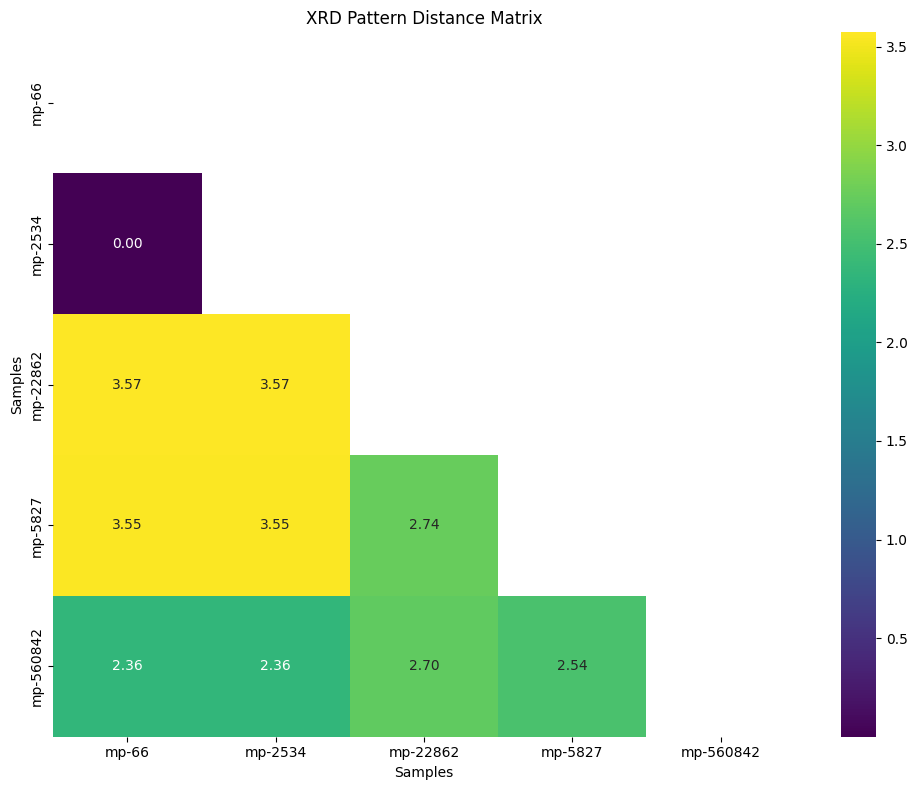

Bottom 3 smallest pairs:
1: mp-2534 - mp-66 : 0.000000
2: mp-560842 - mp-2534 : 2.357620
3: mp-560842 - mp-66 : 2.357620


In [15]:
with MPRester(api()) as mpr:
    test=[
        mpr.get_structure_by_material_id("mp-66"),
        mpr.get_structure_by_material_id("mp-2534"),
        mpr.get_structure_by_material_id("mp-22862"),
        mpr.get_structure_by_material_id("mp-5827"),
        mpr.get_structure_by_material_id("mp-560842"),
    ]
    result=str_strdist(test)
    result=postprocess(result)
    
    visualize_distance_matrix(result, ["mp-66", "mp-2534", "mp-22862", "mp-5827", "mp-560842"])

In [4]:
type(result)

numpy.ndarray

In [23]:
xrd,file=read_xrd_csv("xrd_data")
print(type(xrd[1]))
lin=xrd_strdist(xrd)

<class 'dict'>


AttributeError: 'dict' object has no attribute 'lattice'

In [25]:
xrd[1]["intensity"]

array([0.02784191, 0.02794378, 0.02804633, ..., 0.92996627, 1.00930375,
       1.04364031], shape=(2499,))